## Logistic Regression

- It’s a classification algorithm, that is used where the response variable is categorical. The idea of Logistic Regression is to find a relationship between features and probability of particular outcome.

  - E.g. When we have to predict if a student passes or fails in an exam when the number of hours spent studying is given as a feature, the response variable has two values, pass and fail.

- If the probability is more than 50%, it assigns the value in that particular class else if the probability is less than 50%, the value is assigned to the other class. Therefore, we can say that logistic regression acts as a binary classifier.

###### Working of a Logistic Model
For linear regression, the model is defined by:
$y = \beta_0 + \beta_1x  $       - (i)

and for logistic regression, we calculate probability, i.e. y is the probability of a given variable x belonging to a certain class. Thus, it is obvious that the value of y should lie between 0 and 1.

But, when we use equation(i) to calculate probability, we would get values less than 0 as well as greater than 1. That doesn’t make any sense
.
So, we need to use such an equation which always gives values between 0 and 1, as we desire while calculating the probability.

So here we Use Sigmoid Function

#### Sigmoid function

We use the sigmoid function as the underlying function in Logistic regression. Mathematically and graphically, it is shown as:

<img src="1.gif" width="300">

**Why do we use the Sigmoid Function?**

1)	The sigmoid function’s range is bounded between 0 and 1. Thus it’s useful in calculating the probability for the  Logistic function.

2)	 It’s derivative is easy to calculate than other functions which is useful during gradient descent calculation.

3)	It is a simple way of introducing non-linearity to the model.


### Now Logistic function On Sigmoid Function

<img src="2.jpg" width="300">

### Logit Function
- Logistic regression can be expressed as:

<img src='3.png'>

- where, the left hand side is called the logit or log-odds function, and p(x)/(1-p(x)) is called odds.
- The odds signifies the ratio of probability of success to probability of failure. Therefore, in Logistic Regression, linear combination of inputs are mapped to the log(odds) - the output being equal to 1.

* The cost function for the whole training set is given as :

<img src='4.png' width='800'>

## Logistic And Linear Model

<img src='05.jpg'>

# Pratical Demonstrate Of Logistic Regression

## Importing the libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

## Importing the dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dataset = pd.read_csv('/content/drive/MyDrive/ML/Logistic_Regression/Dataset/student_exam_data_new.csv')

In [ ]:
dataset.head()

,Study Hours,Previous Exam Score,Pass/Fail
0,4.370861,81.889703,0
1,9.556429,72.165782,1
2,7.587945,58.571657,0
3,6.387926,88.827701,1
4,2.404168,81.083870,0


In [ ]:
print("number of row",dataset.shape[0])
print("number of columns",dataset.shape[1])

number of row 500
number of columns 3


In [ ]:
dataset.isnull().sum()

,0
Study Hours,0
Previous Exam Score,0
Pass/Fail,0


In [ ]:
dataset.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
495,False
496,False
497,False
498,False


In [ ]:
data1=dataset['Pass/Fail'].value_counts()
size=dataset['Pass/Fail'].value_counts()
print(data1)

Pass/Fail
0    316
1    184
Name: count, dtype: int64


([<matplotlib.patches.Wedge at 0x7b791df535b0>,
 [Text(-0.44319717128295216, 1.0067652493837824, ''),
  Text(0.4431972655431159, -1.006765207888664, '')],
 [Text(-0.24174391160888298, 0.5491446814820631, '63.2%'),
  Text(0.24174396302351772, -0.5491446588483622, '36.8%')])

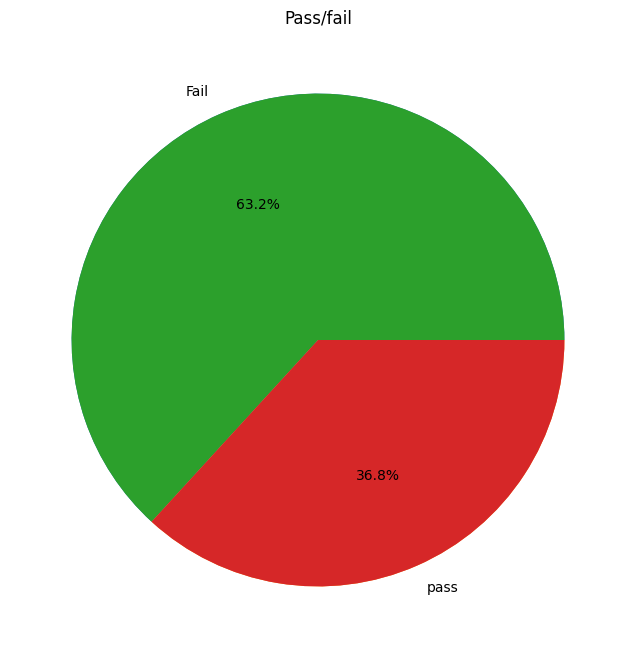

In [ ]:
plt.figure(figsize=(8, 8))
plt.pie(data1, labels=["Fail", "pass"])
plt.title("Pass/fail")
plt.pie(size, autopct="%.1f%%")

<Axes: xlabel='Previous Exam Score', ylabel='Count'>

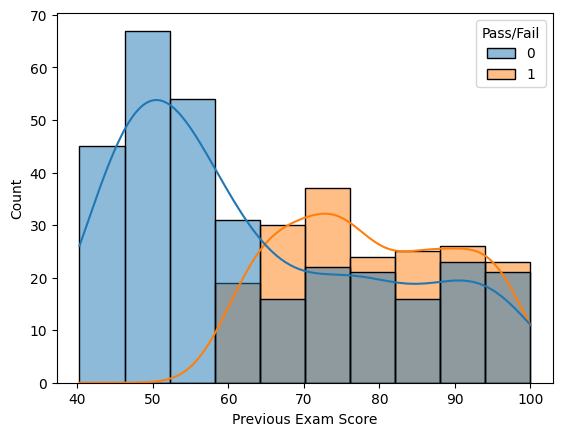

In [ ]:
sns.histplot(data=dataset,x="Previous Exam Score",hue="Pass/Fail",kde=True, bins=10)

<Axes: >

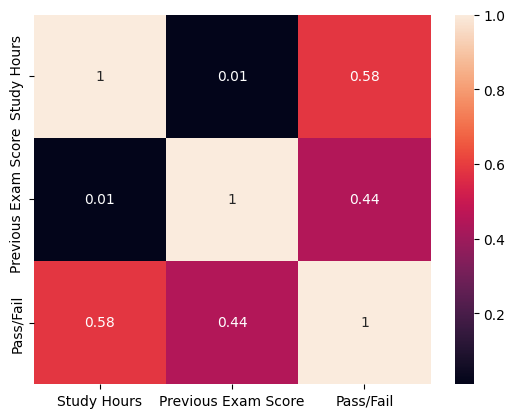

In [ ]:
sns.heatmap(dataset.corr(),annot=True)

<Axes: xlabel='Study Hours', ylabel='Previous Exam Score'>

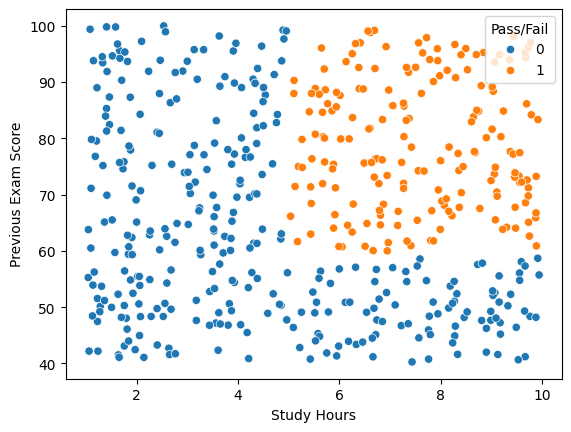

In [ ]:
sns.scatterplot(x=dataset['Study Hours'], y=dataset['Previous Exam Score'], hue = dataset['Pass/Fail'])

In [ ]:
X = dataset.drop(['Pass/Fail'],axis=1)
y = dataset['Pass/Fail']

In [ ]:
X.shape,y.shape

((500, 2), (500,))

## Splitting the dataset into the Training set and Test set

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

## Feature Scaling

**Method 1**

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scale = MinMaxScaler()

X_train_scale = scale.fit_transform(X_train)
X_test_scale = scale.transform(X_test)

**Method 2**

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

## Training the Logistic Regression model on the Training set

In [ ]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression()
classifier.fit(X_train, y_train)

LogisticRegression()

## Predicting the Test set results

In [ ]:
y_pred = classifier.predict(X_test)

In [ ]:
calculation = pd.DataFrame(np.c_[y_test,y_pred], columns = ["Pass/Fail","Pass/Fail predicted"])
calculation

,Pass/Fail,Pass/Fail predicted
0,0,0
1,0,0
2,0,0
3,0,0
4,1,1
...,...,...
120,0,0
121,0,0
122,0,0
123,0,0


## Visualising the Training set results

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score,recall_score,f1_score
from sklearn.metrics import classification_report
log_pred = classifier.predict(X_test)
log_cm= confusion_matrix(y_test,log_pred)
log_acc= accuracy_score(y_test,log_pred)*100
log_prec=precision_score(y_test,log_pred)*100
log_rec=recall_score(y_test,log_pred)*100
log_f1=f1_score(y_test,log_pred)*100
print("accuracy_score: ", log_acc)
print("precision_score: ", log_prec)
print("recall_score: ", log_rec)
print("f1_score: ", log_f1)
print("confusion_matrix: \n", log_cm)

accuracy_score:  86.4
precision_score:  90.0
recall_score:  73.46938775510205
f1_score:  80.89887640449437
confusion_matrix: 
 [[72  4]
 [13 36]]


# **Logistic Regression 86%**

In [ ]:
print(classification_report(y_test,log_pred))

              precision    recall  f1-score   support

           0       0.85      0.95      0.89        76
           1       0.90      0.73      0.81        49

    accuracy                           0.86       125
   macro avg       0.87      0.84      0.85       125
weighted avg       0.87      0.86      0.86       125



# **RANDOM FOREST** 100%

In [ ]:
model = RandomForestClassifier()

In [ ]:
from sklearn.metrics import accuracy_score

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score,recall_score,f1_score
from sklearn.metrics import classification_report
log_pred = model.predict(X_test)
log_cm= confusion_matrix(y_test,log_pred)
log_acc= accuracy_score(y_test,log_pred)*100
log_prec=precision_score(y_test,log_pred)*100
log_rec=recall_score(y_test,log_pred)*100
log_f1=f1_score(y_test,log_pred)*100
print("accuracy_score: ", log_acc)
print("precision_score: ", log_prec)
print("recall_score: ", log_rec)
print("f1_score: ", log_f1)
print("confusion_matrix: \n", log_cm)

accuracy_score:  100.0
precision_score:  100.0
recall_score:  100.0
f1_score:  100.0
confusion_matrix: 
 [[76  0]
 [ 0 49]]


In [ ]:
print(classification_report(y_test,log_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        76
           1       1.00      1.00      1.00        49

    accuracy                           1.00       125
   macro avg       1.00      1.00      1.00       125
weighted avg       1.00      1.00      1.00       125



# **Decisions Tree** 100%

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
tree_model = DecisionTreeClassifier()

In [ ]:
tree_model.fit(X_train, y_train)

DecisionTreeClassifier()

In [ ]:
y_pred = tree_model.predict(X_test)

In [ ]:
print(f'Accuracy score: {accuracy_score(y_test, y_pred)}')

Accuracy score: 1.0


In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score,recall_score,f1_score
from sklearn.metrics import classification_report
log_pred = tree_model.predict(X_test)
log_cm= confusion_matrix(y_test,log_pred)
log_acc= accuracy_score(y_test,log_pred)*100
log_prec=precision_score(y_test,log_pred)*100
log_rec=recall_score(y_test,log_pred)*100
log_f1=f1_score(y_test,log_pred)*100
print("accuracy_score: ", log_acc)
print("precision_score: ", log_prec)
print("recall_score: ", log_rec)
print("f1_score: ", log_f1)
print("confusion_matrix: \n", log_cm)

accuracy_score:  100.0
precision_score:  100.0
recall_score:  100.0
f1_score:  100.0
confusion_matrix: 
 [[76  0]
 [ 0 49]]


In [ ]:
print(classification_report(y_test,log_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        76
           1       1.00      1.00      1.00        49

    accuracy                           1.00       125
   macro avg       1.00      1.00      1.00       125
weighted avg       1.00      1.00      1.00       125



# **KNN CLASSIFIER 100%**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
knn = KNeighborsClassifier()

In [ ]:
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
y_pred = tree_model.predict(X_test)

In [ ]:
print(f'Accuracy score: {accuracy_score(y_test, y_pred)}')

Accuracy score: 1.0


In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score,recall_score,f1_score
from sklearn.metrics import classification_report
log_pred = knn.predict(X_test)
log_cm= confusion_matrix(y_test,log_pred)
log_acc= accuracy_score(y_test,log_pred)*100
log_prec=precision_score(y_test,log_pred)*100
log_rec=recall_score(y_test,log_pred)*100
log_f1=f1_score(y_test,log_pred)*100
print("accuracy_score: ", log_acc)
print("precision_score: ", log_prec)
print("recall_score: ", log_rec)
print("f1_score: ", log_f1)
print("confusion_matrix: \n", log_cm)

accuracy_score:  100.0
precision_score:  100.0
recall_score:  100.0
f1_score:  100.0
confusion_matrix: 
 [[76  0]
 [ 0 49]]


In [ ]:
print(classification_report(y_test,log_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        76
           1       1.00      1.00      1.00        49

    accuracy                           1.00       125
   macro avg       1.00      1.00      1.00       125
weighted avg       1.00      1.00      1.00       125

